In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [6]:
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero Quantity:", (df['Quantity'] == 0).sum())
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())

Negative Quantity: 10624
Zero Quantity: 0
Negative UnitPrice: 2
Zero UnitPrice: 2515


In [7]:
df_clean = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (df['CustomerID'].notna())
].copy()

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))

Original rows: 541909
Clean rows: 397884


In [8]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df_clean[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [11]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [12]:
customer_stats = df_clean.groupby('CustomerID').agg(
    Total_Spending=('TotalAmount', 'sum'),
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Average_Purchase_Value=('TotalAmount', 'mean')
)

customer_stats['Customer_Lifetime_Value'] = (
    customer_stats['Total_Spending'] / customer_stats['Purchase_Frequency']
)

customer_stats.describe()

,Total_Spending,Purchase_Frequency,Average_Purchase_Value,Customer_Lifetime_Value
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272015,68.350506,419.166289
std,8989.230441,7.697998,1467.918896,1796.537944
min,3.750000,1.000000,2.101286,3.450000
25%,307.415000,1.000000,12.365367,178.625000
50%,674.485000,2.000000,17.723119,293.900000
75%,1661.740000,5.000000,24.858417,430.113750
max,280206.020000,209.000000,77183.600000,84236.250000


In [13]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [15]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


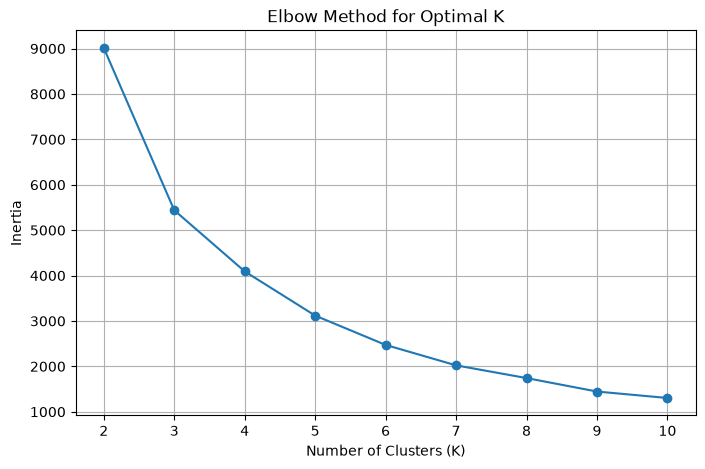

In [16]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [17]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 9012.64
K = 3: Inertia = 5439.30
K = 4: Inertia = 4092.14
K = 5: Inertia = 3118.28
K = 6: Inertia = 2472.57
K = 7: Inertia = 2022.41
K = 8: Inertia = 1742.37
K = 9: Inertia = 1445.63
K = 10: Inertia = 1303.39


In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [19]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


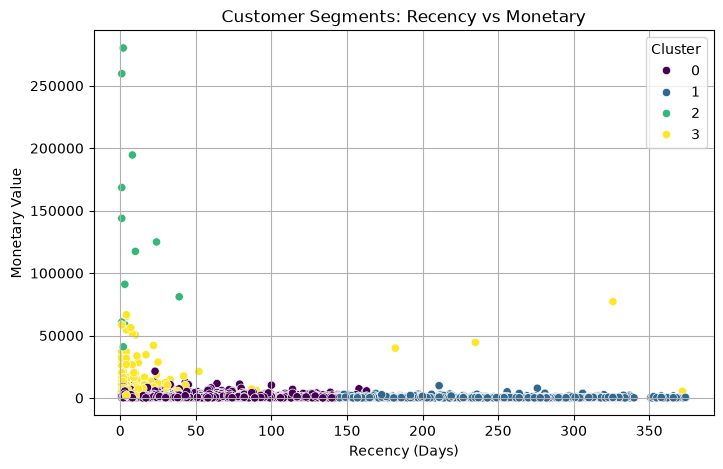

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.show()

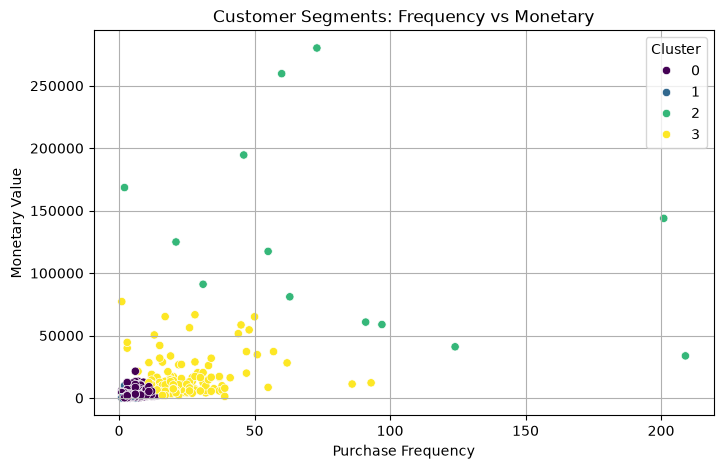

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.show()

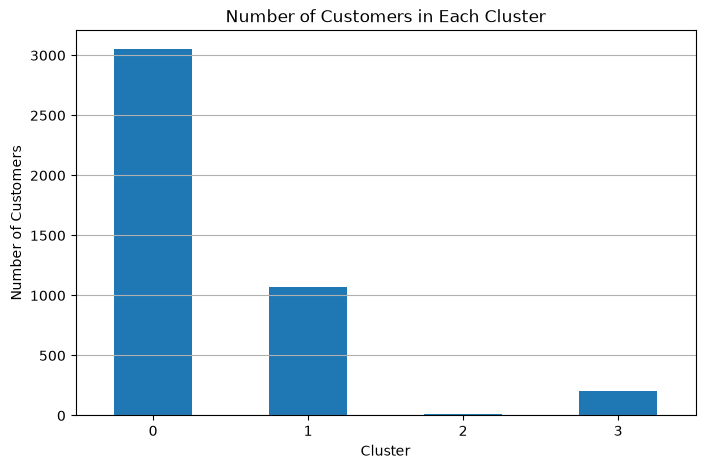

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [22]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

print(cluster_counts)

In [23]:
cluster_names = {
    0: 'Regular Customers',
    1: 'Low-Value / Inactive Customers',
    2: 'VIP / Extremely High-Value Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,Low-Value / Inactive Customers


In [24]:
cluster_profile = rfm.groupby(['Cluster', 'Segment'])[['Recency', 'Frequency', 'Monetary']].mean().round(2)

cluster_profile

,,Recency,Frequency,Monetary
Cluster,Segment,,,
0,Regular Customers,43.70,3.68,1359.05
1,Low-Value / Inactive Customers,248.08,1.55,480.62
2,VIP / Extremely High-Value Customers,7.38,82.54,127338.31
3,Loyal High-Value Customers,15.50,22.33,12709.09


## Marketing Insights

### Cluster 0 — Regular Customers
These customers make moderately frequent purchases and have moderate spending. They represent the largest customer segment.

**Marketing strategy:** Use personalised promotions, product recommendations, seasonal discounts, and loyalty rewards to increase purchase frequency and spending.

### Cluster 1 — Low-Value / Inactive Customers
These customers have the highest recency, meaning they have not purchased recently. They also have relatively low purchase frequency and monetary value.

**Marketing strategy:** Use re-engagement campaigns, personalised discount offers, reminder emails, and limited-time promotions to encourage them to return.

### Cluster 2 — VIP / Extremely High-Value Customers
These customers purchase very frequently, purchased recently, and have exceptionally high monetary value. Although this is a very small group, they are highly valuable to the business.

**Marketing strategy:** Provide VIP loyalty benefits, exclusive offers, early access to new products, personalised services, and premium rewards.

### Cluster 3 — Loyal High-Value Customers
These customers purchase frequently, have purchased recently, and have substantially higher spending than regular customers.

**Marketing strategy:** Strengthen customer loyalty through membership benefits, personalised recommendations, targeted offers, and cross-selling or upselling opportunities.

## Conclusion

Customer segmentation was performed using RFM analysis and K-Means clustering on the Online Retail dataset. After data cleaning, 4,338 customers were analysed based on Recency, Frequency, and Monetary value.

The Elbow Method was used to determine an appropriate number of clusters, and K-Means identified four distinct customer segments: Regular Customers, Low-Value / Inactive Customers, VIP / Extremely High-Value Customers, and Loyal High-Value Customers.

The segmentation provides useful insights into customer purchasing behaviour and can help businesses develop targeted marketing strategies. Regular customers can be encouraged to increase their purchase frequency, inactive customers can be targeted through re-engagement campaigns, and high-value customers can be retained through loyalty and VIP programs.

Overall, customer segmentation can support data-driven marketing decisions, improve customer retention, and help businesses focus their resources on the most valuable customer groups.